In [1]:
%matplotlib inline
#
from multifunbrain import *
from multifunbrain.notebook import *
#
if Path.cwd().name != 'multifun-brain':
    path_root = Path.cwd().parent
    os.chdir(path_root)
#
path_data =  path_root / 'data'
path_fig = path_data / 'figures'
path_ts = path_data / 'atlas_timecourses'
path_corrmat = path_data / 'correlation_matrices'
path_imf_matrices = path_corrmat / 'bold_matrices_from_IMF'
#

### Set the atlas

In [2]:
# Fetch the Harvard-Oxford cortical atlas.
atlas = datasets.fetch_atlas_harvard_oxford(
    'cort-maxprob-thr50-2mm', data_dir=path_data
)
atlas_filename = atlas.maps
atlas_img = image.load_img(atlas_filename)
atlas_data = atlas_img.get_fdata()
#
rois = atlas.labels
rois_label_map = {i: ll for i,ll in enumerate(rois[1:])}
roi_indices = np.unique(list(rois_label_map.keys()))
# Load MNI152 template for the background.
template = load_mni152_template()

[get_dataset_dir] Dataset found in /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/fsl


### Load matrix

In [3]:
fnames = os.listdir(path_imf_matrices)
bold_matrix_test = {}
for fn in fnames:
    pn = path_imf_matrices / fn
    if not pn.is_file():
        fnames.remove(fn)
        continue
    with open(pn, 'rb') as f:
        bold_matrix_test[fn] = pk.load(f)

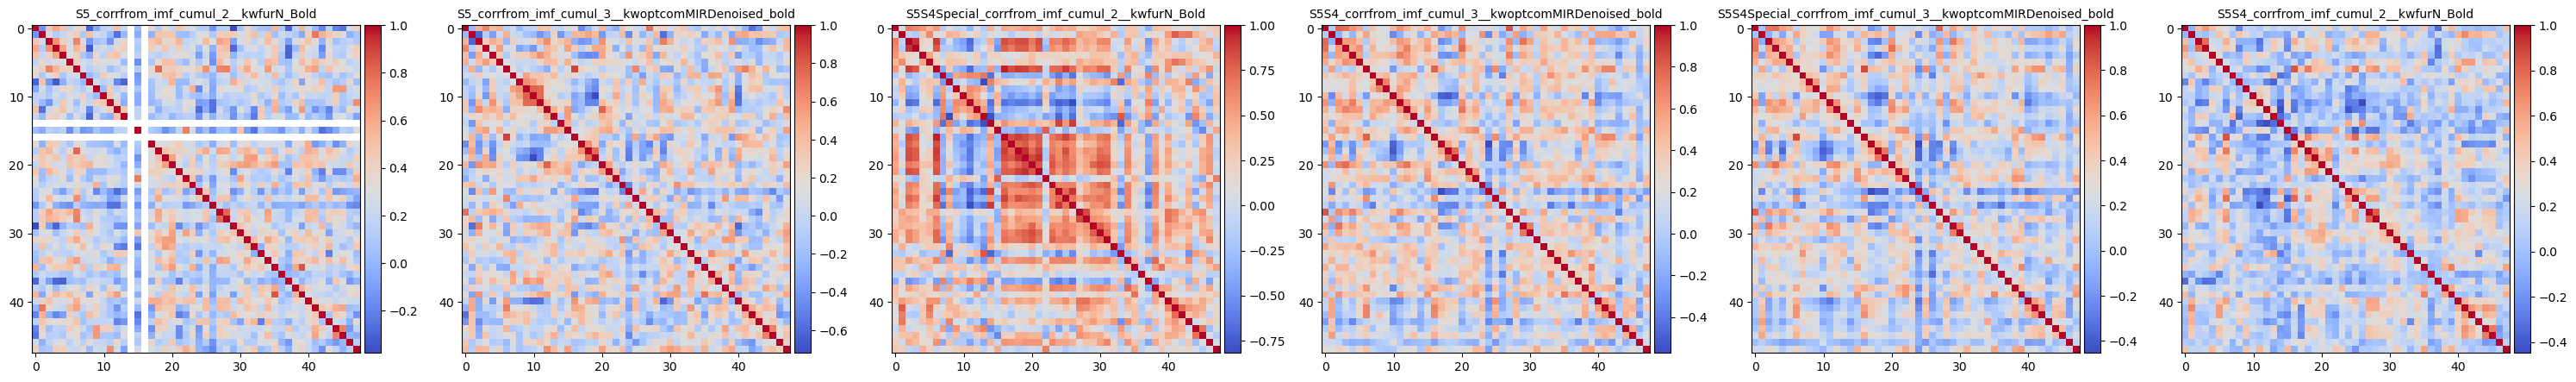

In [4]:
fig, ax = plt.subplots(1, len(fnames), figsize=(5*len(fnames), 5))
for i, fn in enumerate(fnames):
    im = ax[i].imshow(bold_matrix_test[fn], cmap='coolwarm')
    fnn = fn.replace('HarvardOxford_48Parcels', '').replace('.ts.1D.pkl', '')
    ax[i].set_title(fnn, fontsize=10)
    div, cax, clb = imshow_colorbar_caxdivider(im, ax[i])
fig.tight_layout()

In [5]:
fn = fnames[3]
G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(bold_matrix_test[fn]))
G = nx.convert_node_labels_to_integers(G)
#
L, spectrum = graph_laplacian_and_spectrum(G)

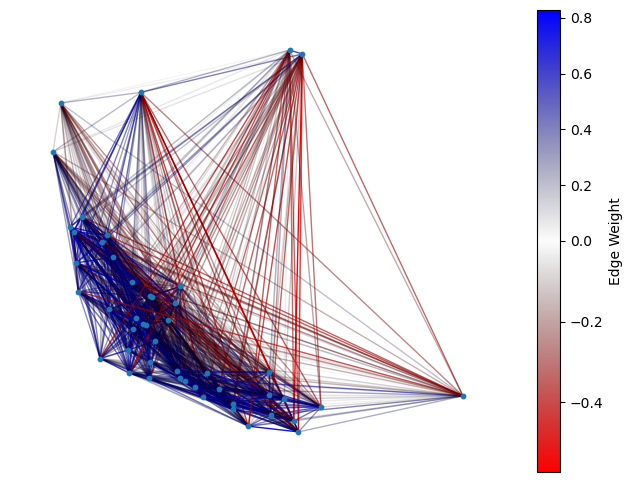

In [6]:
edge_weights = [G[u][v].get('weight', 0) for u, v in G.edges()]
norm = TwoSlopeNorm(vmin=min(edge_weights), vcenter=0, vmax=max(edge_weights))
cmap = LinearSegmentedColormap.from_list(
    'red_transparent_blue',
    [(0.0, (1, 0, 0, 1)),      # Red, opaque
     (0.5, (0, 0, 0, .01)),      # Transparent (white, alpha=0)
     (1.0, (0, 0, 1, 1))],     # Blue, opaque
    N=256
)
edge_colors = [cmap(norm(w)) for w in edge_weights]
#
fig, ax = plt.subplots(figsize=(8,6))
#
nx.draw(G, ax=ax, edge_color=edge_colors, node_size=10)
#
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(edge_weights)
#
plt.colorbar(sm, ax=ax, label='Edge Weight')
plt.show()

In [7]:
A_old = nx.to_numpy_array(G)
A_new = np.abs(A_old)#np.where(A_old < 0, 0, A_old)
G_pos = nx.from_numpy_array(A_new)
Th, Einf, Pinf = compute_threshold_stats_fast(G_pos)
Th, jump = find_threshold_jumps(G_pos)

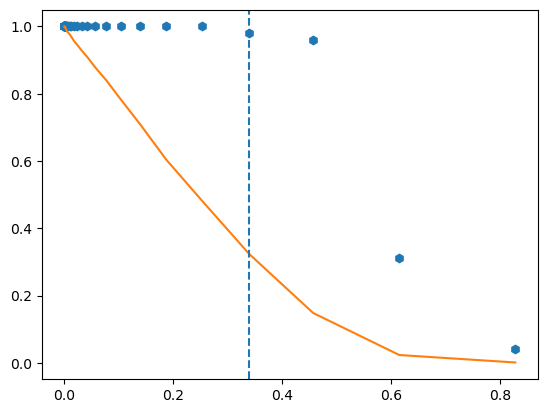

In [8]:
sel_thresh = Th[jump[1]]
plt.plot(Th, Pinf, 'h')
plt.plot(Th, Einf)
plt.axvline(sel_thresh, ls='--')

In [9]:
A_prime = nx.to_numpy_array(G_pos)
A_thresh = np.where(A_prime < sel_thresh, 0, A_prime)
G_pos, lost_nodes_1 = get_giant_component_leftoff(nx.from_numpy_array(A_thresh))

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning: divide by zero encountered in log
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)
/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning: invalid value encountered in multiply
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)


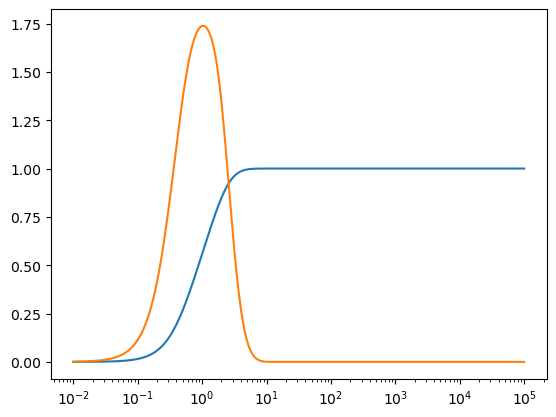

In [10]:
L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
Sm1, dS, VarL, tau  = entropy(spectrum)
plt.plot(tau, Sm1)
plt.plot(tau[1:], dS)
plt.xscale('log')

In [11]:
# Multiscale Analysis on All Correlation Matrices
# Perform graph analysis with three different tau values for each correlation matrix

# Define the three tau multipliers
tau_multipliers = [100, 1, 0.1]
tau_names = ['100/max(λ)', '1/max(λ)', '0.1/max(λ)']

# Initialize storage for results
all_results = {}

print(f"Processing {len(fnames)} correlation matrices with {len(tau_multipliers)} tau values each...")

for fn in fnames:
    print(f"\nProcessing matrix: {fn}")
    
    # Get the correlation matrix
    corr_matrix = bold_matrix_test[fn]
    
    # Create initial graph and get giant component
    G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(corr_matrix))
    G = nx.convert_node_labels_to_integers(G)
    
    # Convert to positive weights only (absolute values)
    A_old = nx.to_numpy_array(G)
    A_new = np.abs(A_old)
    
    # Add small regularization to avoid numerical issues
    A_new = A_new + 1e-12 * np.eye(A_new.shape[0])
    
    G_pos = nx.from_numpy_array(A_new)
    
    # Calculate Laplacian and spectrum with error handling
    try:
        L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
        max_eigenvalue = max(spectrum)
    except np.linalg.LinAlgError:
        print(f"    Warning: Eigenvalue computation failed for {fn}, using normalized Laplacian")
        # Try with normalized Laplacian which is often more numerically stable
        try:
            L_pos, spectrum = graph_laplacian_and_spectrum(G_pos, normalized=True)
            max_eigenvalue = max(spectrum)
        except np.linalg.LinAlgError:
            print(f"    Error: Both regular and normalized Laplacian failed for {fn}, skipping...")
            continue
    
    # Store results for this matrix
    matrix_results = {
        'graph': G_pos,
        'lost_nodes': lost_nodes_0,
        'laplacian': L_pos,
        'spectrum': spectrum,
        'max_eigenvalue': max_eigenvalue,
        'clusters': {}
    }
    
    # Process each tau value
    for i, multiplier in enumerate(tau_multipliers):
        tau = multiplier / max_eigenvalue
        
        print(f"  Processing tau = {tau_names[i]} = {tau:.6f}")
        
        # Compute distance matrix
        rho_m = lambda tau_val: rho_matrix(tau_val, L_pos)
        dists = symmetrized_inverse_distance(tau, rho_m)
        
        # Compute hierarchical clustering
        linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
        
        # Find optimal threshold and clusters
        threshold, *_ = compute_optimal_threshold(linkage_matrix)
        optimal_clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')
        
        # Store clustering results
        matrix_results['clusters'][multiplier] = {
            'tau': tau,
            'linkage_matrix': linkage_matrix,
            'label_list': label_list,
            'threshold': threshold,
            'optimal_clusters': optimal_clusters,
            'n_clusters': len(np.unique(optimal_clusters))
        }
        
        print(f"    Found {len(np.unique(optimal_clusters))} clusters")
    
    all_results[fn] = matrix_results

print(f"\nCompleted analysis for all {len(fnames)} matrices")

Processing 6 correlation matrices with 3 tau values each...

Processing matrix: S5_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
    Error: Both regular and normalized Laplacian failed for S5_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl, skipping...

Processing matrix: S5_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 6.947119
    Found 2 clusters
  Processing tau = 1/max(λ) = 0.069471
    Found 4 clusters
  Processing tau = 0.1/max(λ) = 0.006947
    Found 6 clusters

Processing matrix: S5S4Special_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 4.358098
    Found 3 clusters
  Processing tau = 1/max(λ) = 0.043581
    Found 7 clusters
  Processing tau = 0.1/max(λ) = 0.004358
    Found 6 clusters

Processing matrix: S5S4_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 

In [15]:
# Create separate visualizations for each matrix and tau combination
# Only use matrices that were successfully processed
processed_fnames = [fn for fn in fnames if fn in all_results]
print(f"Creating individual visualizations for {len(processed_fnames)} successfully processed matrices out of {len(fnames)} total")

# Generate a color palette for clusters
colors = plt.cm.tab20(np.linspace(0, 1, 20))  # Up to 20 different colors

# Store all created figures for potential batch operations
all_figures = []

for matrix_idx, fn in enumerate(processed_fnames):
    # Get clean matrix name for display
    matrix_name = fn.replace('HarvardOxford_48Parcels_', '').replace('.ts.1D.pkl', '')
    print(f"\nProcessing visualizations for matrix: {matrix_name}")
    
    for tau_idx, multiplier in enumerate(tau_multipliers):
        # Create individual figure for each brain map
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        
        # Get clustering results
        cluster_result = all_results[fn]['clusters'][multiplier]
        optimal_clusters = cluster_result['optimal_clusters']
        lost_nodes = all_results[fn]['lost_nodes']
        n_clusters = cluster_result['n_clusters']
        tau_value = cluster_result['tau']
        
        # Create node colors based on cluster assignments
        node_colors = [colors[cluster_id % len(colors)] for cluster_id in optimal_clusters]
        
        # Insert white color for lost nodes (nodes not in giant component)
        indices_to_insert = sorted(lost_nodes)
        node_colors_all = node_colors.copy()
        for idx in reversed(indices_to_insert):
            node_colors_all.insert(idx, 'white')
        
        # Create colormap
        cmap = ListedColormap(node_colors_all)
        
        # Plot brain map
        plotting.plot_stat_map(
            atlas_img, 
            bg_img=template, 
            axes=ax, 
            cmap=cmap,
            colorbar=False,
        )
        
        # Set comprehensive title
    
        
        # Save individual figure
        safe_matrix_name = matrix_name.replace('/', '_').replace(' ', '_')
        safe_tau_name = tau_names[tau_idx].replace('/', '_').replace(' ', '_')
        filename = f'brain_partition_{safe_matrix_name}_tau_{safe_tau_name}.pdf'
        fig.savefig(path_fig / filename, bbox_inches='tight', transparent=True, dpi=300)
        print(f"  Saved: {filename}")
        
        # Store figure reference
        all_figures.append({
            'figure': fig,
            'matrix': matrix_name,
            'tau': tau_names[tau_idx],
            'filename': filename
        })
        plt.close('all')

print(f"\nCompleted visualization creation. Generated {len(all_figures)} individual brain maps.")
print(f"All figures saved to: {path_fig}")

Creating individual visualizations for 5 successfully processed matrices out of 6 total

Processing visualizations for matrix: S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold
  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_100_max(λ).pdf
  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_1_max(λ).pdf
  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_0.1_max(λ).pdf

Processing visualizations for matrix: S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold
  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_100_max(λ).pdf
  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_1_max(λ).pdf
  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_0.1_max(λ).pdf

Processing visualizations for matrix: S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold
  Saved: brain_partition_S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_100_max(λ).pdf
  Saved: brai